# Discrete Uniform Probability Distribution

## 1. Definition

A set of discrete outcomes that can be indexed with sequential integers, and each outcome has equal probability, like rolling a fair die.

## 2. Intuition

Every outcome has equal probability.

## 3. Parameter

Unlike Bernoulli ($\theta$) and Binomial ($N$ and $\theta$), there is no probability parameter.

## 4. Support

The support are the values between $a$ and $b$.

Number of values: $$N = b - a + 1 $$

## 5. Probability Mass Function

$$f(y;\{a,b\}) = \frac{1}{b - a + 1}$$

for $$a \leq y \leq b$$

otherwise $0$

## 6. Cumulative Distribution Function

$$F(y;a,b)=\frac{y-a+1}{b-a+1}$$

## 7. Moments

Mean: $\frac{a+b}{2}$


Variance: $\frac{(b-a+1)^{2}-1}{12}$

## 8. NumPy Implementation

In [1]:
import numpy as np
import matplotlib as plt

In [116]:
class DiscreteUniform:
    def __init__(self, a:int, b:int):
        if a>b:
            a,b = b,a

        self.a = np.asarray(a)
        self.b = np.asarray(b)

        self.N = self.b - self.a +1
        self.theta = 1 / self.N

        print(self.a)
        print(self.b)
        print(self.N)
        print(self.theta)

    def pmf(self, n:int):
        n = np.asarray(n)

        P = np.zeros_like(n, dtype=float)
        P[n<self.a] = 0.0
        P[n>self.b] = 0.0

        mask = (n>=self.a) & (n<=self.b) & (n==np.floor(n))
        P[mask] = self.theta
        return P

    def cdf(self, n:int):
        n = np.asarray(n)

        F = np.zeros_like(n, dtype=float)
        F[n<self.a] = 0.0
        F[n>=self.b] = 1.0

        pmf = self.pmf(np.arange(self.a,self.b+1))

        cumulative_probabilities = np.cumsum(pmf)
        
        mask = (n>=self.a) & (n<=self.b) & (n==np.floor(n))

        F[mask] = cumulative_probabilities[n[mask]-self.a]

        return F

    def mean(self):
        return 0.5 * (self.a + self.b)

    def variance(self):
        return (self.N**2 - 1) / 12

    def sample(self, size=1, random_state=None):

        rng = np.random.default_rng(random_state)
        uniform_samples = rng.random(size)
        cdf = np.cumsum(self.pmf(np.arange(self.a,self.b+1)))
        return np.searchsorted(cdf, uniform_samples) + self.a
        
        

In [127]:
class DiscreteUniform:
    """
    Discrete uniform distribution over the integers

        {a, a + 1, ..., b}

    where a <= b.
    """

    def __init__(self, a: int, b: int):
        if not isinstance(a, (int, np.integer)):
            raise TypeError("a must be an integer.")

        if not isinstance(b, (int, np.integer)):
            raise TypeError("b must be an integer.")

        if a > b:
            raise ValueError("a must be less than or equal to b.")

        self.a = int(a)
        self.b = int(b)

        self.N = self.b - self.a + 1
        self.probability = 1.0 / self.N
        self.support = np.arange(self.a, self.b + 1)

    def pmf(self, n):
        """
        Probability mass function.

        Every integer in the support has probability 1 / N.
        Values outside the support receive probability 0.
        """

        n = np.asarray(n)

        P = np.zeros_like(n, dtype=float)

        valid = (
            (n >= self.a)
            & (n <= self.b)
            & (n == np.floor(n))
        )

        P[valid] = self.probability

        return P

    def cdf(self, n):
        """
        Cumulative distribution function:

            F(n) = P(X <= n)

        The CDF is defined for both integer and non-integer inputs.
        """

        n = np.asarray(n)

        F = np.zeros_like(n, dtype=float)

        # All probability has accumulated at and above b.
        F[n >= self.b] = 1.0

        # Values between a and b.
        valid = (n >= self.a) & (n < self.b)

        indices = np.floor(n[valid]).astype(int) - self.a

        cumulative_probabilities = np.cumsum(
            self.pmf(self.support)
        )

        F[valid] = cumulative_probabilities[indices]

        return F

    def mean(self):
        """
        Expected value:

            E[X] = (a + b) / 2
        """

        return 0.5 * (self.a + self.b)

    def variance(self):
        """
        Variance:

            Var(X) = (N^2 - 1) / 12
        """

        return (self.N**2 - 1) / 12

    def sample(self, size=1, random_state=None):
        """
        Generate samples using inverse-transform sampling.
        """

        if not isinstance(size, (int, np.integer)):
            raise TypeError("size must be an integer.")

        if size < 1:
            raise ValueError("size must be at least 1.")

        rng = np.random.default_rng(random_state)

        uniform_samples = rng.random(size)

        cumulative_probabilities = np.cumsum(
            self.pmf(self.support)
        )

        # Protect against small floating-point accumulation errors.
        cumulative_probabilities[-1] = 1.0

        sampled_indices = np.searchsorted(
            cumulative_probabilities,
            uniform_samples,
            side="right",
        )

        return sampled_indices + self.a

    def plot(self, figsize=(10, 4)):
        """
        Plot the PMF and CDF.
        """

        import matplotlib.pyplot as plt

        pmf_values = self.pmf(self.support)
        cdf_values = self.cdf(self.support)

        fig, axes = plt.subplots(1, 2, figsize=figsize)

        axes[0].bar(self.support, pmf_values)
        axes[0].set_title("Discrete Uniform PMF")
        axes[0].set_xlabel("Outcome")
        axes[0].set_ylabel("Probability")
        axes[0].set_xticks(self.support)
        axes[0].set_ylim(0, min(1.0, self.probability * 1.25))
        axes[0].grid(True, axis="y")

        axes[1].step(
            self.support,
            cdf_values,
            where="post",
        )
        axes[1].scatter(
            self.support,
            cdf_values,
        )
        axes[1].set_title("Discrete Uniform CDF")
        axes[1].set_xlabel("Outcome")
        axes[1].set_ylabel("Cumulative probability")
        axes[1].set_xticks(self.support)
        axes[1].set_ylim(0, 1.05)
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()

PMF: [0.  0.2 0.2 0.2 0. ]
CDF: [0.  0.2 0.2 0.8 1.  1. ]
Mean: 5.0
Variance: 2.0
Samples: [6 5 7 6 3 7 6 6 3 5]


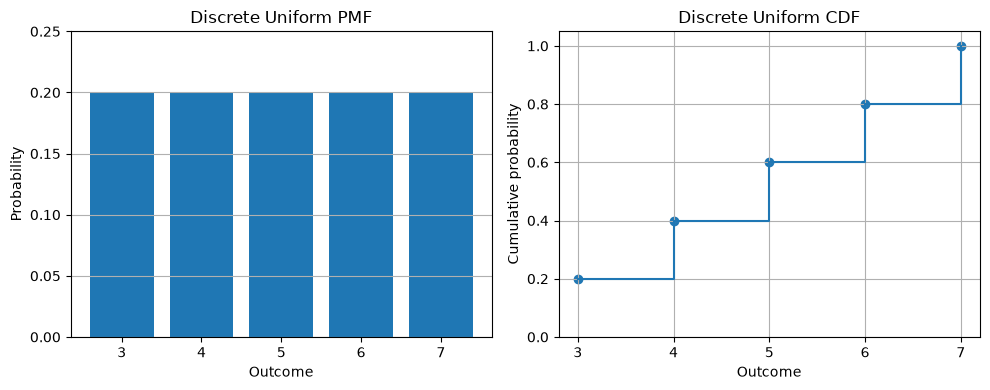

In [129]:
distribution = DiscreteUniform(a=3, b=7)

print("PMF:", distribution.pmf([2, 3, 4, 7, 8]))
print("CDF:", distribution.cdf([2, 3, 3.7, 6, 7, 8]))
print("Mean:", distribution.mean())
print("Variance:", distribution.variance())
print("Samples:", distribution.sample(size=10, random_state=42))

distribution.plot()